# Results figures

Every figure of thesis section 7, regenerated from the cached data produced by NB1-9 and the cluster sweeps. No transfer matrices are built here; each cell loads the caches, redoes the fits, and saves one figure. Rerunning the notebook after new cluster rungs land re-plots everything.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics, LsqFit
thesis_plot_theme!()

const V = load("../results/data/alcaraz_velocity.jld2", "v")
const M8 = load("../results/data/nb8_master.jld2", "done")
const CL = "../results/data/cluster"

# chord variable and helpers used by every entropy fit
W(t, T) = log((2T / pi) * sin(pi * t / T))
ph(z) = angle(-z)
dphw(a, b) = mod(a - b + pi, 2pi) - pi

load_arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath(CL, file), "done") if k[1] == label && !haskey(v, :error))

# cluster arms: entropy domes, and the half-integer eigenvalue ladders
ent_arm(p) = load_arm("sweep_ent_p$(p).jld2", "ent_p$(p)")
fine_arm(p) = load_arm("sweep_rtm_eigs_p$(p)_fine.jld2", "rtm_eigs_p$(p)_fine")

# last T whose profile still follows the chord line; past it the power method has left the
# physical branch and the profile is an artefact
ent_max = Dict(0.0 => 15.0, 0.1 => 8.0, 0.3 => 3.0, 0.5 => 2.0)

# re-derive the physical branch along a ladder with the robust selector
function robust_chain(arm)
    out = Dict{Float64,Tuple{Int,Bool}}()
    ref = nothing
    for T in sort(collect(keys(arm)))
        theta = arm[T].theta
        i0, rec = pick_phys_robust(theta, ref)
        out[T] = (i0, rec)
        rec && (ref = theta[i0])
    end
    return out
end

# follow the physical branch by predicting its unwrapped phase: the ±partner sits at the same
# modulus but ~π away, and the phase advance per rung can exceed π at large p, so neither modulus
# dominance nor nearest-complex tracking is safe on its own.
function phase_chain(arm)
    Ts = sort(collect(keys(arm)))
    out = Dict{Float64,Int}(); Phi = Dict{Float64,Float64}(); okT = Float64[]; cost = Dict{Float64,Float64}()
    slope = nothing; prevT = nothing; mprev = 0.0
    for (n, T) in enumerate(Ts)
        theta = arm[T].theta
        mags = abs.(theta)
        if n == 1
            i0 = argmax(mags)
            out[T] = i0; Phi[T] = ph(theta[i0]); cost[T] = 0.0; push!(okT, T)
            prevT = T; mprev = mags[i0]
            continue
        end
        # every block member is a candidate: near the ± degeneracy the partner can carry the
        # larger modulus, so only the predicted phase identifies the physical branch
        cand = [i for i in eachindex(theta) if abs(mags[i] - mprev) / mprev < 0.20]
        isempty(cand) && continue
        if slope === nothing
            # advance per rung can exceed π, so the wrapped step is ambiguous: seed with the
            # candidate advance that keeps the next rungs most consistent
            Tnext = [t for t in Ts if t > T][1:min(3, count(>(T), Ts))]
            bestadv = nothing; bestscore = Inf; besti = cand[1]
            for i in cand, kk in 0:2
                adv = dphw(ph(theta[i]), Phi[prevT]) + 2pi * kk
                adv <= 0.05 && continue
                sl = adv / (T - prevT); phi = Phi[prevT] + adv
                score = 0.0; pv = phi; pt = T
                for t2 in Tnext
                    pr = pv + sl * (t2 - pt)
                    bc2 = Inf
                    for tt in arm[t2].theta
                        b2 = ph(tt); k2 = round((pr - b2) / (2pi))
                        for k3 in (k2 - 1, k2, k2 + 1)
                            bc2 = min(bc2, abs(b2 + 2pi * k3 - pr))
                        end
                    end
                    score += bc2
                end
                score < bestscore && (bestscore = score; bestadv = adv; besti = i)
            end
            out[T] = besti; cost[T] = 0.0
            Phi[T] = Phi[prevT] + bestadv
        else
            pred = Phi[prevT] + slope * (T - prevT)
            best = cand[1]; bphi = 0.0; bcost = Inf
            for i in cand
                base = ph(theta[i])
                k = round((pred - base) / (2pi))
                for kk in (k - 1, k, k + 1)
                    phi = base + 2pi * kk
                    cst = abs(phi - pred)
                    cst < bcost && (bcost = cst; best = i; bphi = phi)
                end
            end
            bcost > 1.0 && continue              # no candidate matches the winding: skip the rung
            out[T] = best; Phi[T] = bphi; cost[T] = bcost
        end
        slope = (Phi[T] - Phi[prevT]) / (T - prevT)
        prevT = T; mprev = mags[out[T]]; push!(okT, T)
    end
    return out, Phi, okT, cost
end

mkpath("../results/imgs")
println("caches loaded; v(p) = ", V)
for p in (0.0, 0.1, 0.3, 0.5)
    e = ent_arm(p)
    @printf("ent p=%.1f: T=%g–%g (%d rungs), clean to T=%g\n",
            p, minimum(keys(e)), maximum(keys(e)), length(e), ent_max[p])
end

caches loaded; v(p) = Dict

(0.0 => 1.9999404782208832, 0.4 => 4.595846282902569, 0.3 => 3.9672293388813595, 0.5 => 5.21213856052121, 0.2 => 3.325605554583303, 0.1 => 2.6701643009334437)
ent p=0.0: T=2–18 (17 rungs), clean to T=15
ent p=0.1: T=2–12 (11 rungs), clean to T=8


ent p=0.3: T=2–10 (9 rungs), clean to T=3
ent p=0.5: T=2–10 (9 rungs), clean to T=2


## The entropy route at the integrable point

Prediction: the Renyi-2 temporal entropy follows the chord profile with slope c/8 in the real part, and its imaginary part is flat at pi*c/16.

At the times we reach, the imaginary part sits above that asymptote by a finite-time correction that decays as T^(-1/2). Panel (c) therefore plots the plateau against T^(-1/2), where that correction is a straight line and the intercept is the asymptotic value. Reading c from the intercept is what removes the bias; the red star marks where the intercept would sit for c=1/2.

T= 6  plateau = 0.1289
T= 8  plateau = 0.1243


T=10  plateau = 0.1218
T=12  plateau = 0.1221
T=14  plateau = 0.1218
asymptotic πc/16 at c=1/2 = 0.0982


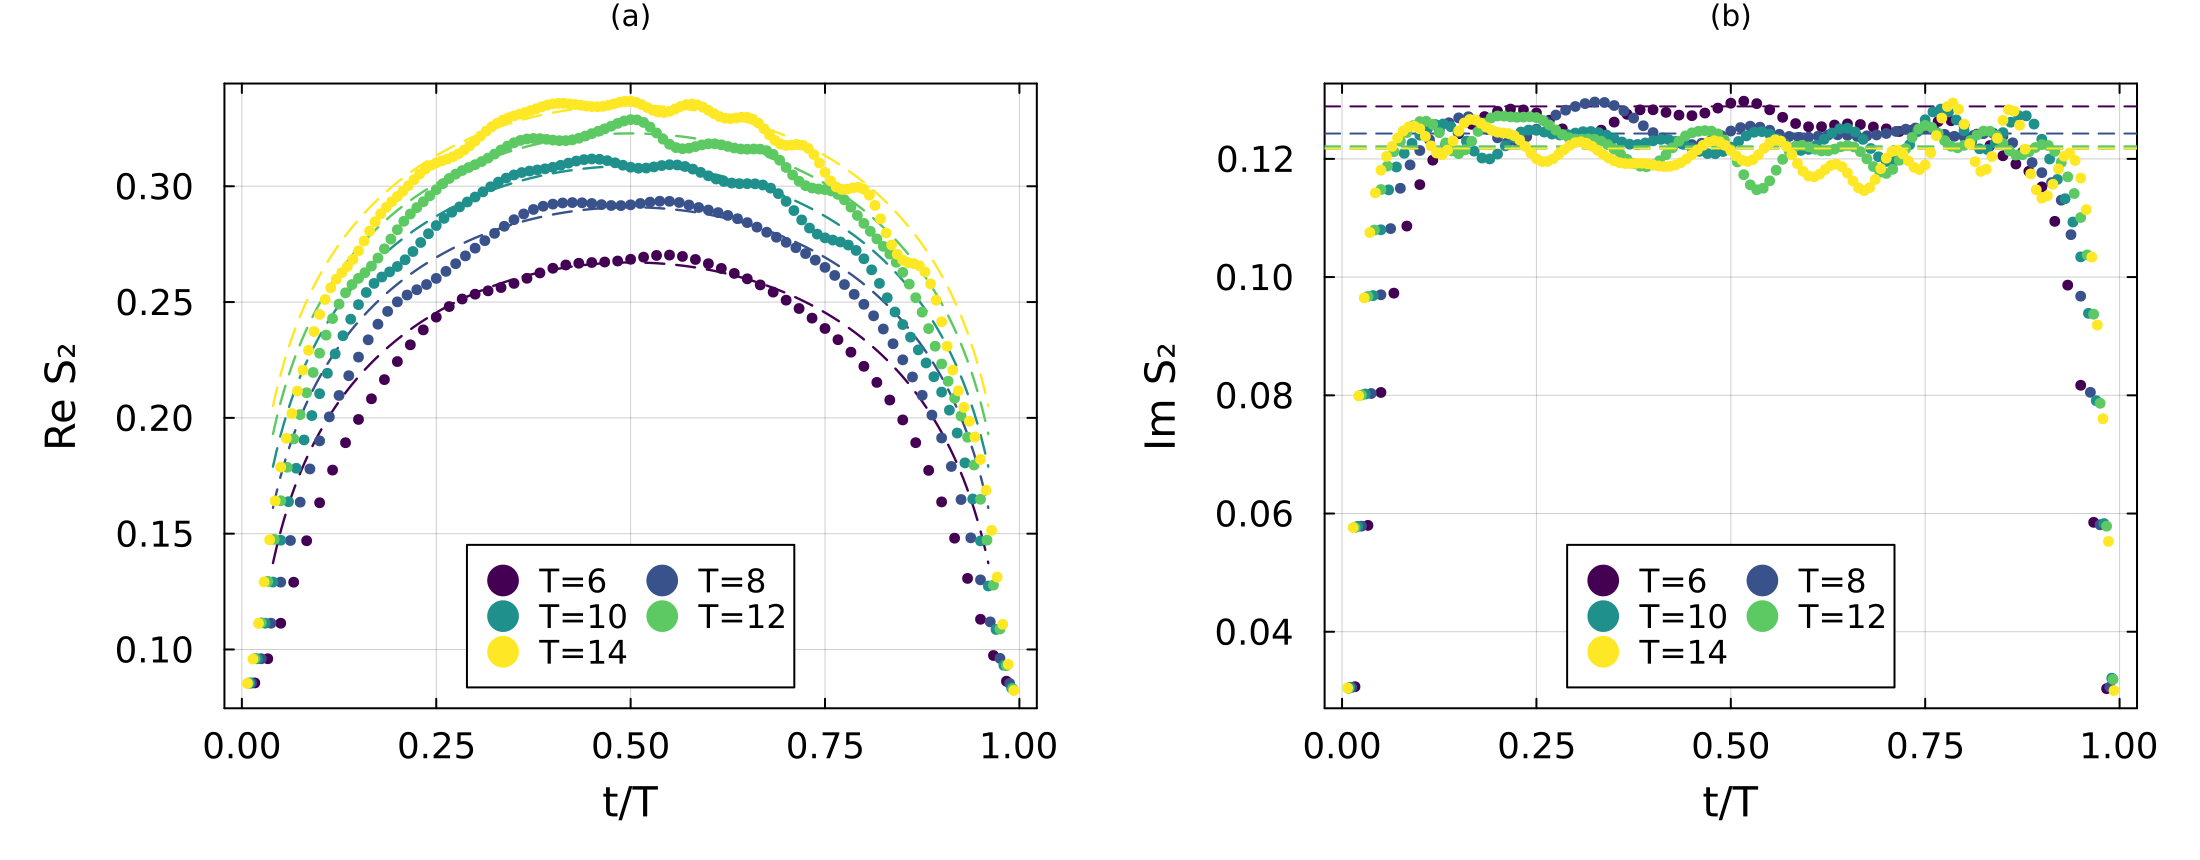

In [2]:
p0 = ent_arm(0.0)
p0_T = sort([T for T in keys(p0) if T <= ent_max[0.0]])
Tshow = [T for T in p0_T if iseven(Int(T)) && T >= 6]
pal = cgrad(:viridis, length(Tshow), categorical=true)

# panel a: Re S2 against t/T, with the c=1/2 chord curve at a fitted offset
pa = plot(xlabel="t/T", ylabel="Re S₂", legend=:bottom, legendcolumns=2, title="(a)", titlefontsize=10)
for (i, T) in enumerate(Tshow)
    s2 = real.(p0[T].s2_base)
    n = length(s2)
    ts = range(T/(n+1), T - T/(n+1), length=n)
    bulk = (n÷4):(3n÷4)
    s0 = mean(s2[bulk] .- (0.5/8) .* W.(ts[bulk], T))
    scatter!(pa, ts ./ T, s2, color=pal[i], ms=3, msw=0, label="T=$(Int(T))")
    tt = range(0.04, 0.96, length=200)
    plot!(pa, tt, (0.5/8) .* W.(tt .* T, T) .+ s0, color=pal[i], lw=1.2, ls=:dash, label="")
end

# panel b: Im S2 against t/T, one colour per T, with the measured plateau of each
pb = plot(xlabel="t/T", ylabel="Im S₂", legend=:bottom, legendcolumns=2, title="(b)", titlefontsize=10)
plateau(T) = mean(imag.(p0[T].s2_base)[max(1, length(p0[T].s2_base)÷2 - 1):(length(p0[T].s2_base)÷2 + 2)])
for (i, T) in enumerate(Tshow)
    s2 = imag.(p0[T].s2_base)
    n = length(s2)
    scatter!(pb, range(1/(n+1), 1 - 1/(n+1), length=n), s2, color=pal[i], ms=3, msw=0, label="T=$(Int(T))")
    hline!(pb, [plateau(T)], color=pal[i], lw=1.0, ls=:dash, label="")
end

fig = plot(pa, pb, layout=(1,2), size=(1100, 430), margin=6Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_domes_p0.png")
for T in Tshow
    @printf("T=%2d  plateau = %.4f\n", Int(T), plateau(T))
end
@printf("asymptotic πc/16 at c=1/2 = %.4f\n", pi/32)
fig

The real part collapses onto the chord curves at c = 1/2 over the whole usable window, and the imaginary part forms the predicted plateau, falling from 0.130 at T=4 to 0.118 at T=15 towards pi c/16 = 0.098. Fitting the T^(-1/2) finite-time form to the plateau and extrapolating gives c = 0.55, the absolute read quoted in section 7.1 of the thesis.

## The entropy route under frustration

The dome survives only inside a window that shrinks with p. The cell fits the real part against the chord variable inside each clean window, pools all T of the window in one fit, and reads the calibrated central charge as c = (1/2) x slope(p)/slope(0). The windows come from the two-part dome test of NB9 (single hump and no selector repair).

per-T chord slope (c = 8*slope):


  p=0.0 T= 2.0  c=   0.511  R2=0.91
  p=0.0 T= 3.0  c=   0.764  R2=0.99


  p=0.0 T= 4.0  c=   0.695  R2=0.99
  p=0.0 T= 5.0  c=   0.667  R2=0.98
  p=0.0 T= 6.0  c=   0.629  R2=0.97
  p=0.0 T= 7.0  c=   0.738  R2=0.96
  p=0.0 T= 8.0  c=   0.747  R2=0.98
  p=0.0 T= 9.0  c=   0.668  R2=0.97
  p=0.0 T=10.0  c=   0.655  R2=0.94
  p=0.0 T=11.0  c=   0.597  R2=0.85
  p=0.0 T=12.0  c=   0.584  R2=0.90
  p=0.0 T=13.0  c=   0.537  R2=0.78
  p=0.0 T=14.0  c=   0.615  R2=0.95
  p=0.0 T=15.0  c=   0.587  R2=0.95
  p=0.0 T=16.0  c=  27.640  R2=0.30   (past the window)
  p=0.0 T=17.0  c=  -1.958  R2=0.00   (past the window)
  p=0.0 T=18.0  c=  38.400  R2=0.43   (past the window)
  p=0.1 T= 2.0  c=   0.946  R2=0.97
  p=0.1 T= 3.0  c=   0.838  R2=0.99
  p=0.1 T= 4.0  c=   0.620  R2=0.97
  p=0.1 T= 5.0  c=   0.607  R2=0.97
  p=0.1 T= 6.0  c=   0.640  R2=0.98
  p=0.1 T= 7.0  c=   0.697  R2=0.99
  p=0.1 T= 8.0  c=   0.727  R2=0.99
  p=0.1 T= 9.0  c=   5.169  R2=0.99   (past the window)
  p=0.1 T=10.0  c=   5.343  R2=0.99   (past the window)
  p=0.1 T=11.0  c=   3.706  R2=0.99 


0.0   0.08067    0.645       0.500            576


0.1   0.08522    0.682       0.528            153
0.3   0.30485    2.439       1.889            26
0.5   0.99907    7.993       6.192            11


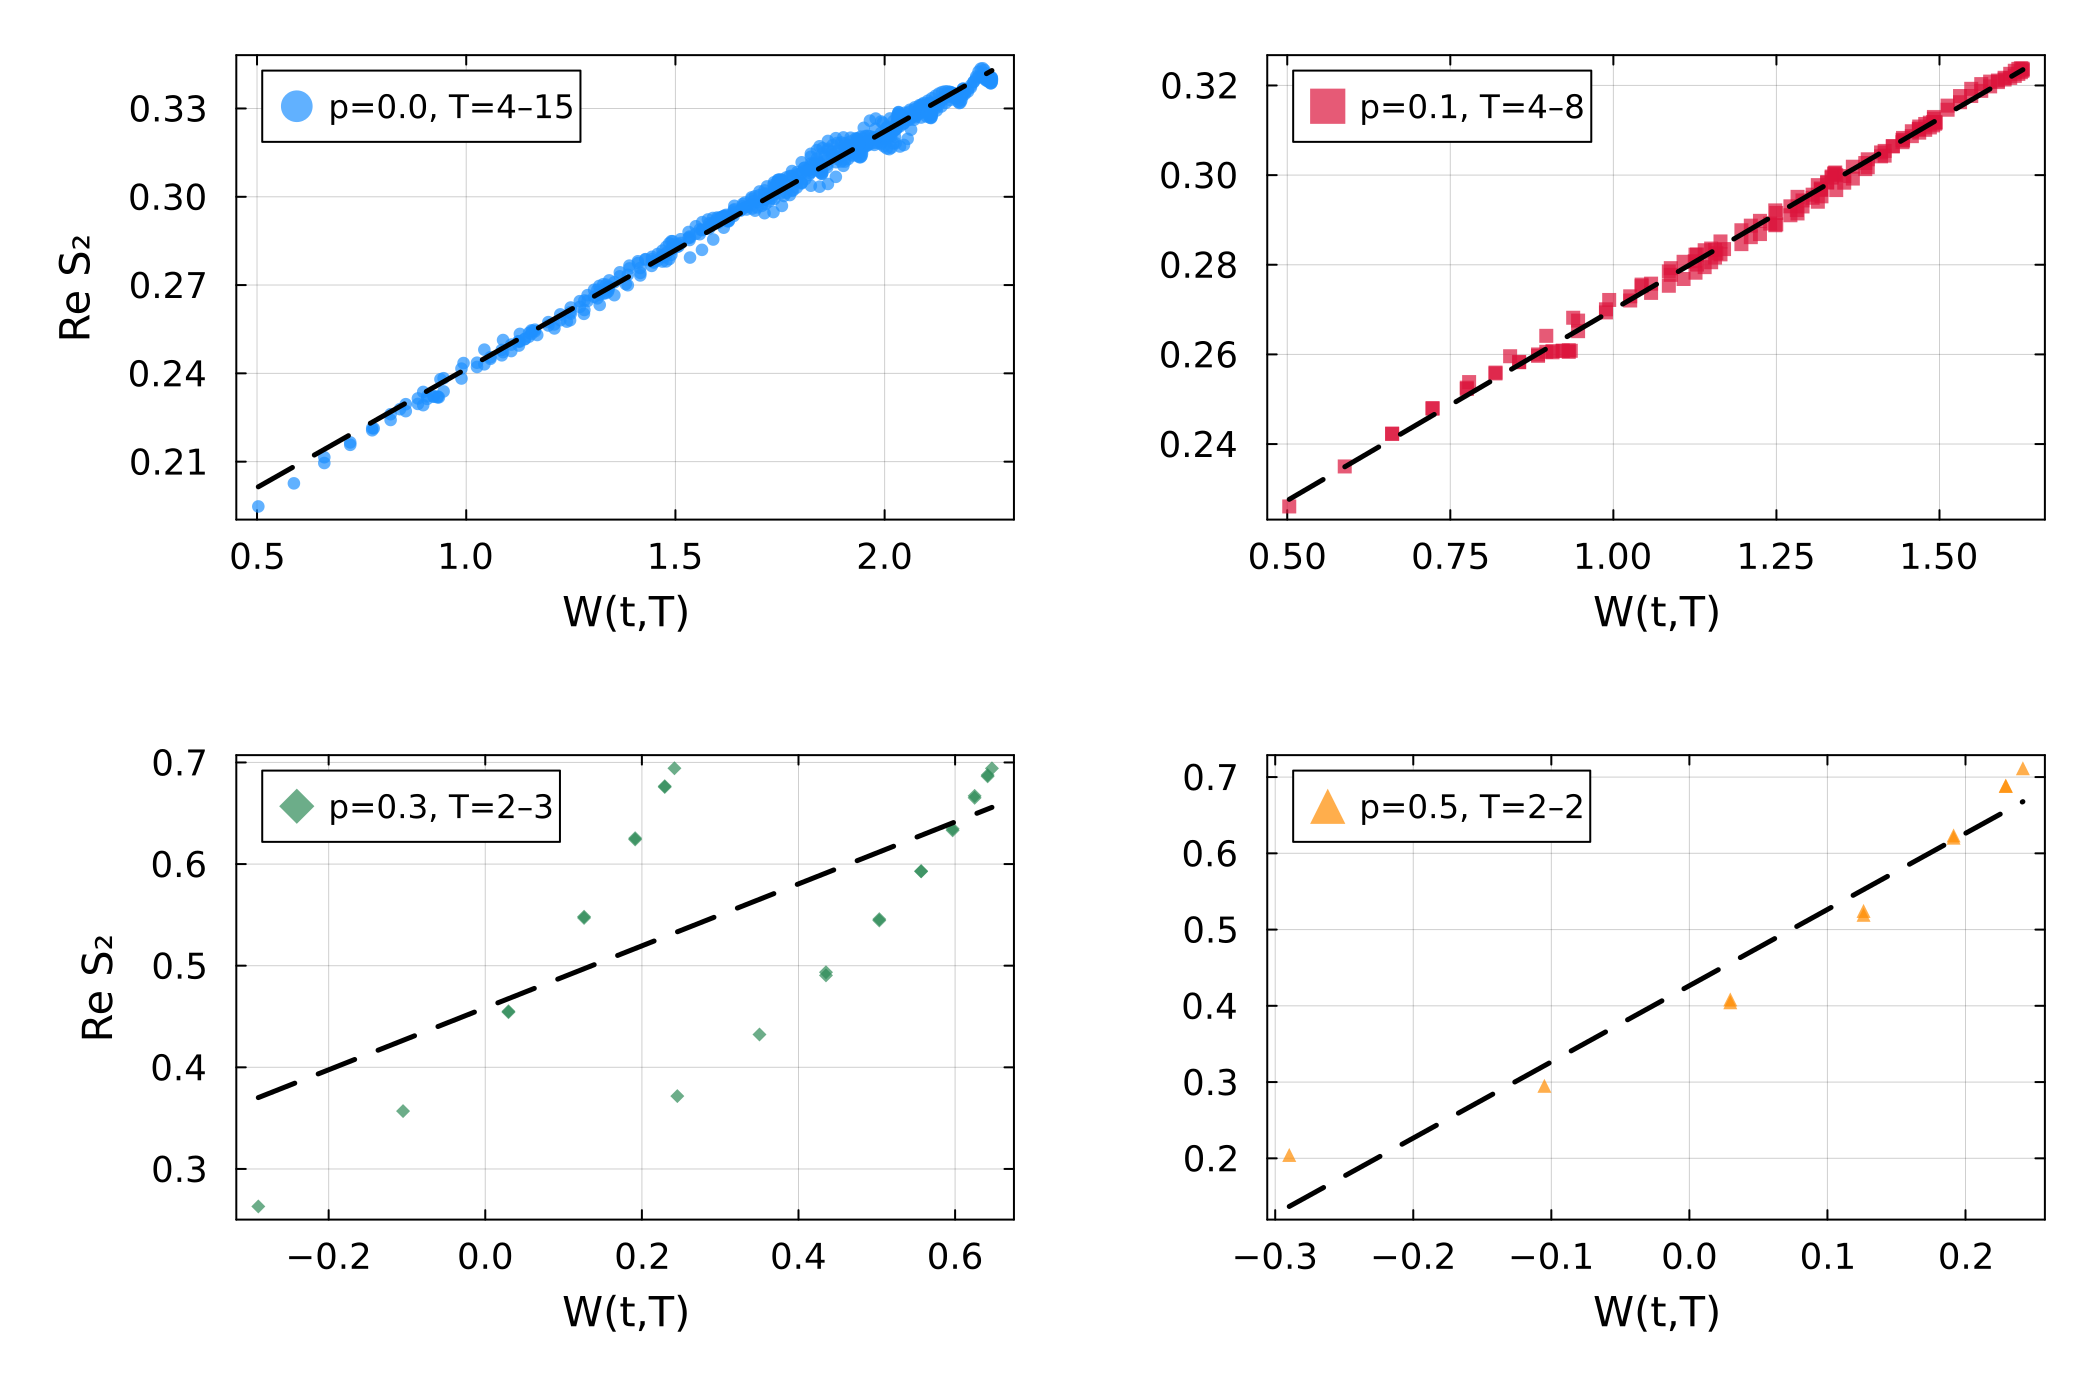

In [3]:
clean_win = Dict(p => (p == 0.0 ? 4.0 : (p == 0.1 ? 4.0 : 2.0), ent_max[p]) for p in (0.0, 0.1, 0.3, 0.5))
prof_p = Dict(p => Dict(T => e.s2_base for (T, e) in ent_arm(p)) for p in (0.0, 0.1, 0.3, 0.5))

lin(x, q) = q[1] .* x .+ q[2]

# slope of one profile against the chord variable, on the middle half of the cuts
function chord_slope(s2, T)
    s2r = real.(s2); n = length(s2r)
    ts = range(T/(n+1), T - T/(n+1), length=n)
    bulk = (n÷4):(3n÷4)
    xs = W.(ts[bulk], T); ys = s2r[bulk]
    fit = curve_fit(lin, xs, ys, [0.06, 0.5])
    res = ys .- lin(xs, fit.param)
    r2 = 1 - sum(res.^2) / sum((ys .- mean(ys)).^2)
    return fit.param[1], r2, xs, ys
end

# per-T diagnostic: where the profile stops giving a conformal slope
println("per-T chord slope (c = 8*slope):")
for p in (0.0, 0.1, 0.3, 0.5)
    for T in sort(collect(keys(prof_p[p])))
        s, r2, _, _ = chord_slope(prof_p[p][T], T)
        mark = T <= clean_win[p][2] ? "" : "   (past the window)"
        @printf("  p=%.1f T=%4.1f  c=%8.3f  R2=%.2f%s\n", p, T, 8s, r2, mark)
    end
end
println()

slopes = Dict{Float64,Float64}(); icepts = Dict{Float64,Float64}(); npts = Dict{Float64,Int}()
panels = []
for p in (0.0, 0.1, 0.3, 0.5)
    lo, hi = clean_win[p]
    xs = Float64[]; ys = Float64[]
    for T in sort(collect(keys(prof_p[p])))
        lo <= T <= hi || continue
        _, _, wx, wy = chord_slope(prof_p[p][T], T)
        append!(xs, wx); append!(ys, wy)
    end
    fit = curve_fit(lin, xs, ys, [0.06, 0.5])
    slopes[p] = fit.param[1]; icepts[p] = fit.param[2]; npts[p] = length(xs)
    pan = plot(xlabel="W(t,T)", ylabel=p in (0.0, 0.3) ? "Re S₂" : "", legend=:topleft)
    scatter!(pan, xs, ys, color=P_COLOR[p], marker=P_MARKER[p], ms=3.5, msw=0, alpha=0.7,
             label=@sprintf("p=%.1f, T=%g–%g", p, lo, hi))
    wr = range(minimum(xs), maximum(xs), length=50)
    plot!(pan, wr, lin(wr, fit.param), color=:black, ls=:dash, label="")
    push!(panels, pan)
end
fig = plot(panels..., layout=(2,2), size=(1050, 700), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_chordfits_p.png")
println("p      slope      c_raw=8s    c_cal=0.5*s/s0   pooled pts")
for p in (0.0, 0.1, 0.3, 0.5)
    @printf("%.1f   %.5f    %.3f       %.3f            %d\n", p, slopes[p], 8slopes[p], 0.5*slopes[p]/slopes[0.0], npts[p])
end
fig

Inside the clean windows the chord fits stay near the Ising slope: the per-time reads at p=0.1 sit between 0.42 and 0.56. At p = 0.3 and 0.5 the usable window ends at T = 3 and 2, too short for the conformal asymptotics, which is why no central charge is quoted there. This figure is not currently used by the thesis.

## Where the eigenvector route ends

Prediction: the route breaks where the transfer matrix nears an exceptional point, diagnosed by the phase rigidity of the dominant pair collapsing. Panel a shows the rigidity against T for every p with eigenvector data. Panel b shows the p=0.1 chord scatter with the past-wall points included: the T > 9 points leave the line the clean window defines.

p=0.0  r: 0.29 at T=2  ->  5e-08 at T=18
p=0.1  r: 0.085 at T=2  ->  2.3e-07 at T=12


p=0.3  r: 0.051 at T=2  ->  9.4e-08 at T=10
p=0.5  r: 0.014 at T=2  ->  1 at T=10


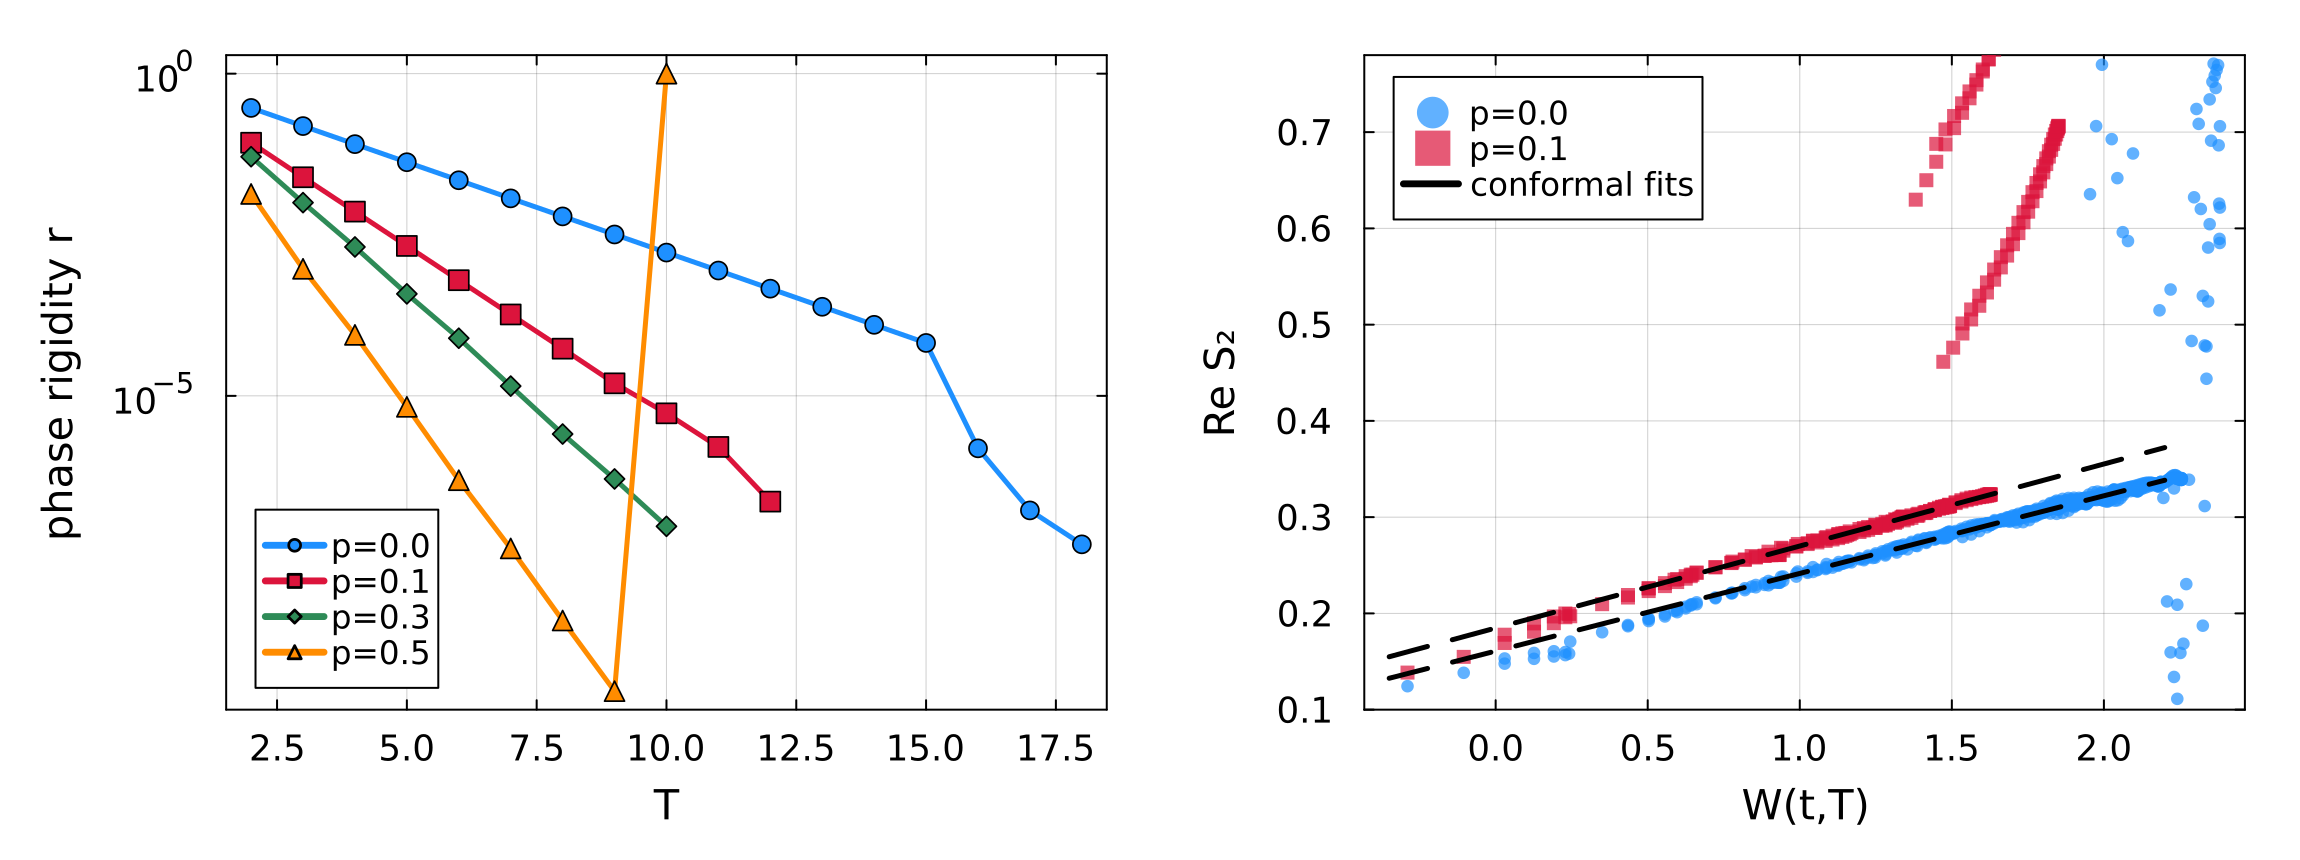

In [4]:
# panel a: rigidity of the physical pair vs T, per p
pa = plot(xlabel="T", ylabel="phase rigidity r", yscale=:log10, legend=:bottomleft)
rig_src = Dict(p => Dict(T => e.rigidity[e.i0] for (T, e) in ent_arm(p) if !isempty(e.rigidity))
               for p in (0.0, 0.1, 0.3, 0.5))
for p in (0.0, 0.1, 0.3, 0.5)
    d = rig_src[p]; Ts = sort(collect(keys(d)))
    isempty(Ts) && continue
    plot!(pa, Ts, [d[T] for T in Ts], color=P_COLOR[p], marker=P_MARKER[p], ms=5, label="p=$(p)")
end

# panel b: chord scatter. Same colour and marker throughout each coupling — past the wall the
# points simply leave the line, which is the whole message.
pb = plot(xlabel="W(t,T)", ylabel="Re S₂", legend=:topleft, ylims=(0.1, 0.78))
for p in (0.0, 0.1)
    first = true
    for T in sort([T for T in keys(prof_p[p]) if T <= ent_max[p] + 2])
        _, _, wx, wy = chord_slope(prof_p[p][T], T)
        scatter!(pb, wx, wy, color=P_COLOR[p], marker=P_MARKER[p],
                 ms=3.5, msw=0, alpha=0.7, label=first ? "p=$(p)" : "")
        first = false
    end
end
# fit lines added after both scatters so their legend entry comes last
for p in (0.0, 0.1)
    wr = range(-0.35, 2.2, length=40)
    plot!(pb, wr, slopes[p] .* wr .+ icepts[p], color=:black, ls=:dash,
          label=p == 0.1 ? "conformal fits" : "")
end

fig = plot(pa, pb, layout=(1,2), size=(1150, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_wall.png")
for p in (0.0, 0.1, 0.3, 0.5)
    d = rig_src[p]; Ts = sort(collect(keys(d)))
    isempty(Ts) || @printf("p=%.1f  r: %.2g at T=%g  ->  %.2g at T=%g\n", p, d[Ts[1]], Ts[1], d[Ts[end]], Ts[end])
end
fig

The rigidity falls geometrically at every coupling and faster as p grows, and the p=0.1 profiles leave the conformal line where it reaches its floor. Notebook 8 carries the corrected reading of the fall itself: per temporal site it is flat, so the falling curves here are the extensive decay of an overlap, and the per-site value 0.94 to 0.79 across p is what the coupling actually changes.

## Locating the wall on the entropy profile

A conformal profile is linear in W with slope c/8. The cell below plots the p=0.1 profiles at T=9 and T=10 against that line, with cuts from the two halves of the strip marked separately.

At T=9 the profile follows the line; at T=10 it does not. Past that step the power method has converged to something other than the physical eigenvectors, so the shape of the T=10 curve is an artefact and only the time of the departure is used.

T=8  peak Re S2 = 0.324  n_maxima = 1  max deviation from the c=1/2 line = 0.048
T=9  peak Re S2 = 0.870  n_maxima = 1  max deviation from the c=1/2 line = 0.567


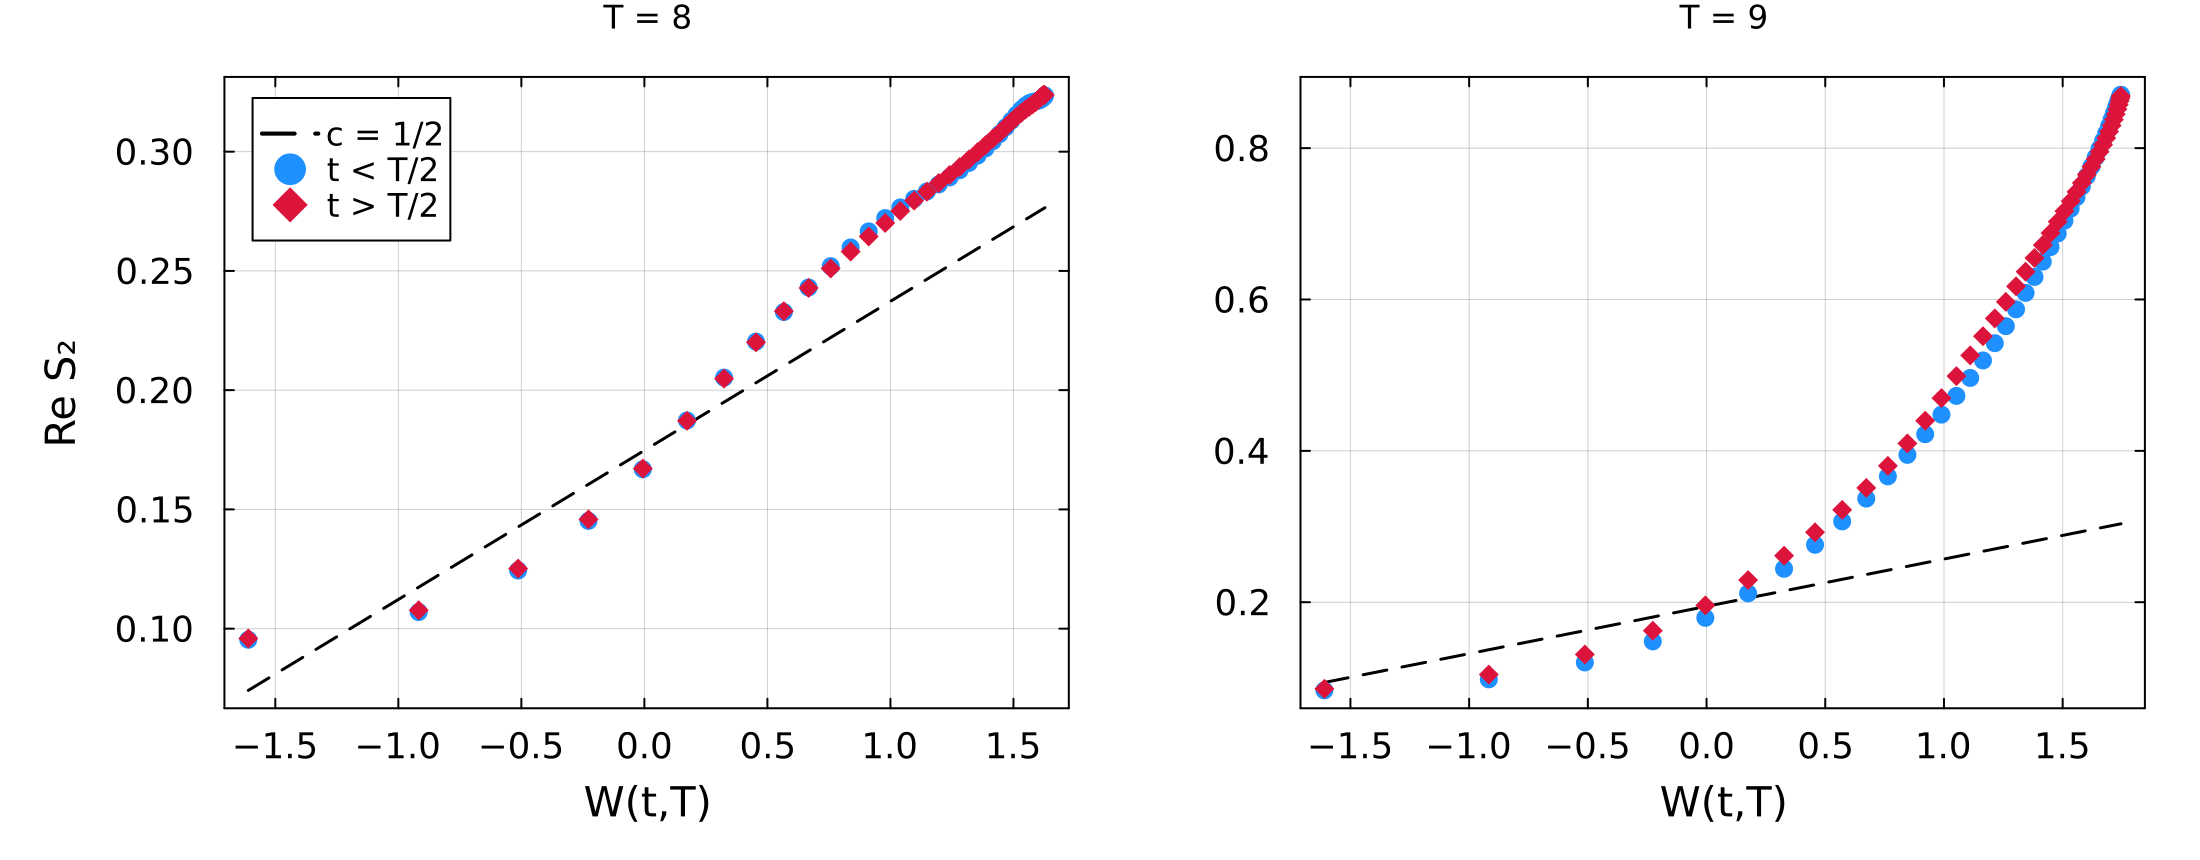

In [5]:
arm01 = ent_arm(0.1)
Tpair = (ent_max[0.1], ent_max[0.1] + 1)      # last good rung and the first past it

panels = []
for T in Tpair
    s2 = real.(arm01[T].s2_base)
    n = length(s2)
    ts = range(T/(n+1), T - T/(n+1), length=n)
    Ws = W.(ts, T)
    first_half = [i for i in 1:n if ts[i] <= T/2]
    second_half = [i for i in 1:n if ts[i] > T/2]

    # conformal line: slope c/8 at c=1/2, offset fixed on the small-W points
    small_W = [i for i in 1:n if Ws[i] < 0.5]
    s0 = mean(s2[small_W] .- (0.5/8) .* Ws[small_W])
    Wr = range(minimum(Ws), maximum(Ws), length=50)

    pan = plot(xlabel="W(t,T)", ylabel=(T == Tpair[1] ? "Re S₂" : ""), legend=(T == Tpair[1] ? :topleft : false),
               title="T = $(Int(T))", titlefontsize=11)
    plot!(pan, Wr, (0.5/8) .* Wr .+ s0, color=:black, ls=:dash, lw=1.5, label="c = 1/2")
    scatter!(pan, Ws[first_half], s2[first_half], color=:dodgerblue, marker=:circle, ms=5, msw=0, label="t < T/2")
    scatter!(pan, Ws[second_half], s2[second_half], color=:crimson, marker=:diamond, ms=5, msw=0, label="t > T/2")
    push!(panels, pan)

    deviation = maximum(abs.(s2 .- ((0.5/8) .* Ws .+ s0)))
    n_maxima = count(i -> 1 < i < n && s2[i] > s2[i-1] && s2[i] > s2[i+1], 1:n)
    @printf("T=%g  peak Re S2 = %.3f  n_maxima = %d  max deviation from the c=1/2 line = %.3f\n",
            T, maximum(s2), n_maxima, deviation)
end
fig = plot(panels..., layout=(1,2), size=(1100, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_broken_dome.png")
fig

On the last usable time the profile is a single dome on the conformal line; one step later the peak has doubled and a second maximum appears. Past that point the iteration no longer converges to the physical eigenvectors, so the shape carries no physical meaning and only the time of the break is used, to locate the wall.

## The spectral route at the integrable point

The eigenvalue-only ladder reaches T=20 at p=0. Panel a traces mu0 in the complex plane (dual unitarity: constant radius, winding phase). Panel b shows the corrected Eq.(3) fit of the unwrapped phase. The boundary exponent panel compares the free and fixed boundary states over the same displayed window.

p=0 eq3 over T=2–20: C=-0.0318  c=0.486


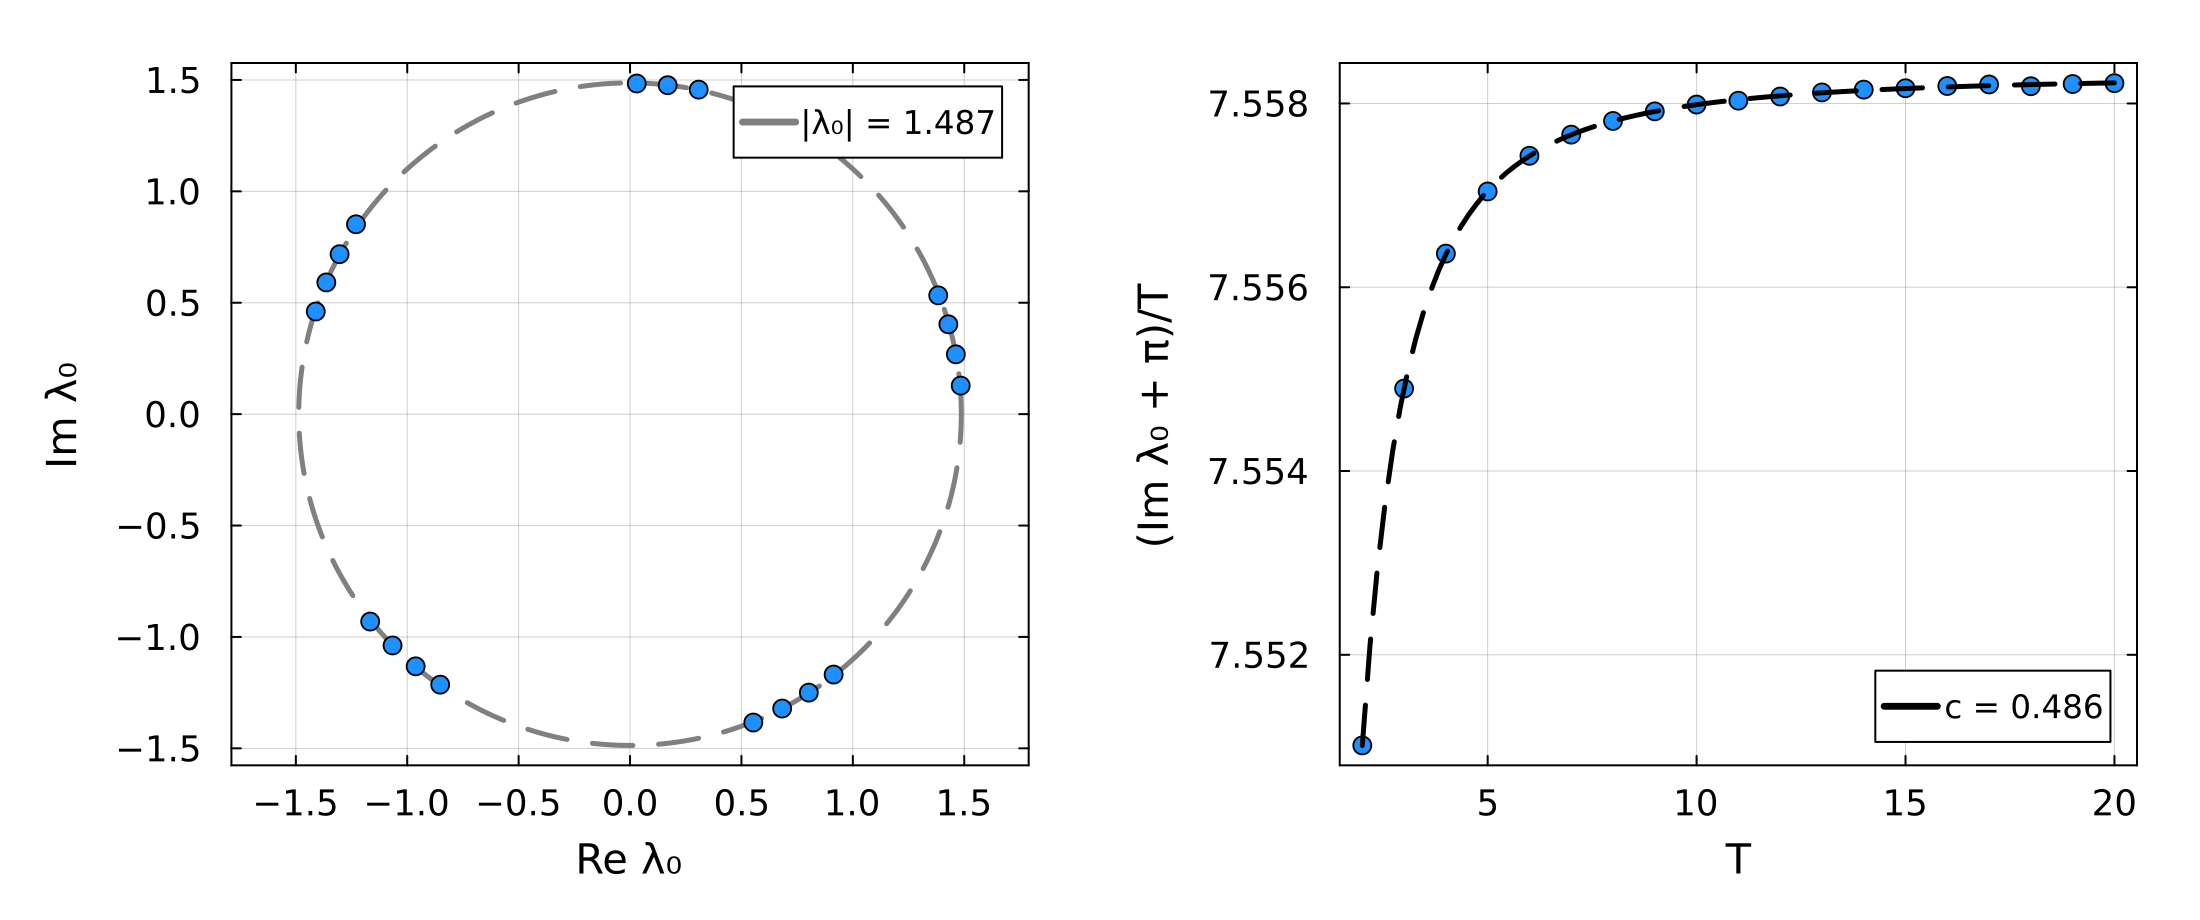

In [6]:
eig0 = load_arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0")
ch0, Phi0, ok0, cst0 = phase_chain(eig0)
fb = findfirst(T -> cst0[T] >= 0.02, ok0); Ts0 = fb === nothing ? ok0 : ok0[1:fb-1]
th0 = [eig0[T].theta[ch0[T]] for T in Ts0]

# panel a: complex-plane circle
pa = plot(xlabel="Re λ₀", ylabel="Im λ₀", aspect_ratio=:equal, legend=:topright)
r0 = mean(abs.(th0))
phis = range(0, 2pi, length=300)
plot!(pa, r0 .* cos.(phis), r0 .* sin.(phis), color=:gray, ls=:dash, label=@sprintf("|λ₀| = %.3f", r0))
scatter!(pa, real.(th0), imag.(th0), color=P_COLOR[0.0], marker=P_MARKER[0.0], ms=5, label="")

# panel b: Eq.(3) on the unwrapped phase, B pinned at -π
phase_unwrapped = [Phi0[T] for T in Ts0]
eq3f(T, q) = q[1] .* T .+ q[2] .+ q[3] ./ T .+ q[4] ./ T.^3
ff0 = curve_fit(eq3f, Ts0, phase_unwrapped, [1.0, -3.0, -0.2, 0.0])
phase_unwrapped = phase_unwrapped .- 2pi * round((ff0.param[2] + pi) / (2pi))
y = (phase_unwrapped .+ pi) ./ Ts0
eq3(T, q) = q[1] .+ q[2] ./ T.^2 .+ q[3] ./ T.^4
fit0 = curve_fit(eq3, Ts0, y, [0.5, -0.2, 0.0])
c_eq3_p0 = 24 * V[0.0] * abs(fit0.param[2]) / pi
pb = plot(xlabel="T", ylabel="(Im λ₀ + π)/T", legend=:bottomright)
scatter!(pb, Ts0, y, color=P_COLOR[0.0], marker=P_MARKER[0.0], ms=5, label="")
Tr = range(minimum(Ts0), maximum(Ts0), length=100)
plot!(pb, Tr, eq3(Tr, fit0.param), color=:black, ls=:dash, label=@sprintf("c = %.3f", c_eq3_p0))

fig = plot(pa, pb, layout=(1,2), size=(1100, 460), margin=6Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_spectral_p0.png")
@printf("p=0 eq3 over T=%g–%g: C=%.4f  c=%.3f\n", Ts0[1], Ts0[end], fit0.param[2], c_eq3_p0)
fig

The modulus stays constant at 1.487 while the phase winds through the whole T = 2 to 20 ladder, the emergent dual unitarity. The corrected Eq. (3) fit returns c = 0.48 with the branch constant converging to B = -3.141, and the Casimir coefficient |C| = 0.0318 sits within 3 per cent of the free-fermion value pi/96.

free  |X+⟩  T=2–9  n=8  x1=0.4965  (per-time x from 0.452 to 0.503)
fixed |Up⟩  T=2–9  n=8  x1=1.9963  (per-time x from 1.819 to 1.978)


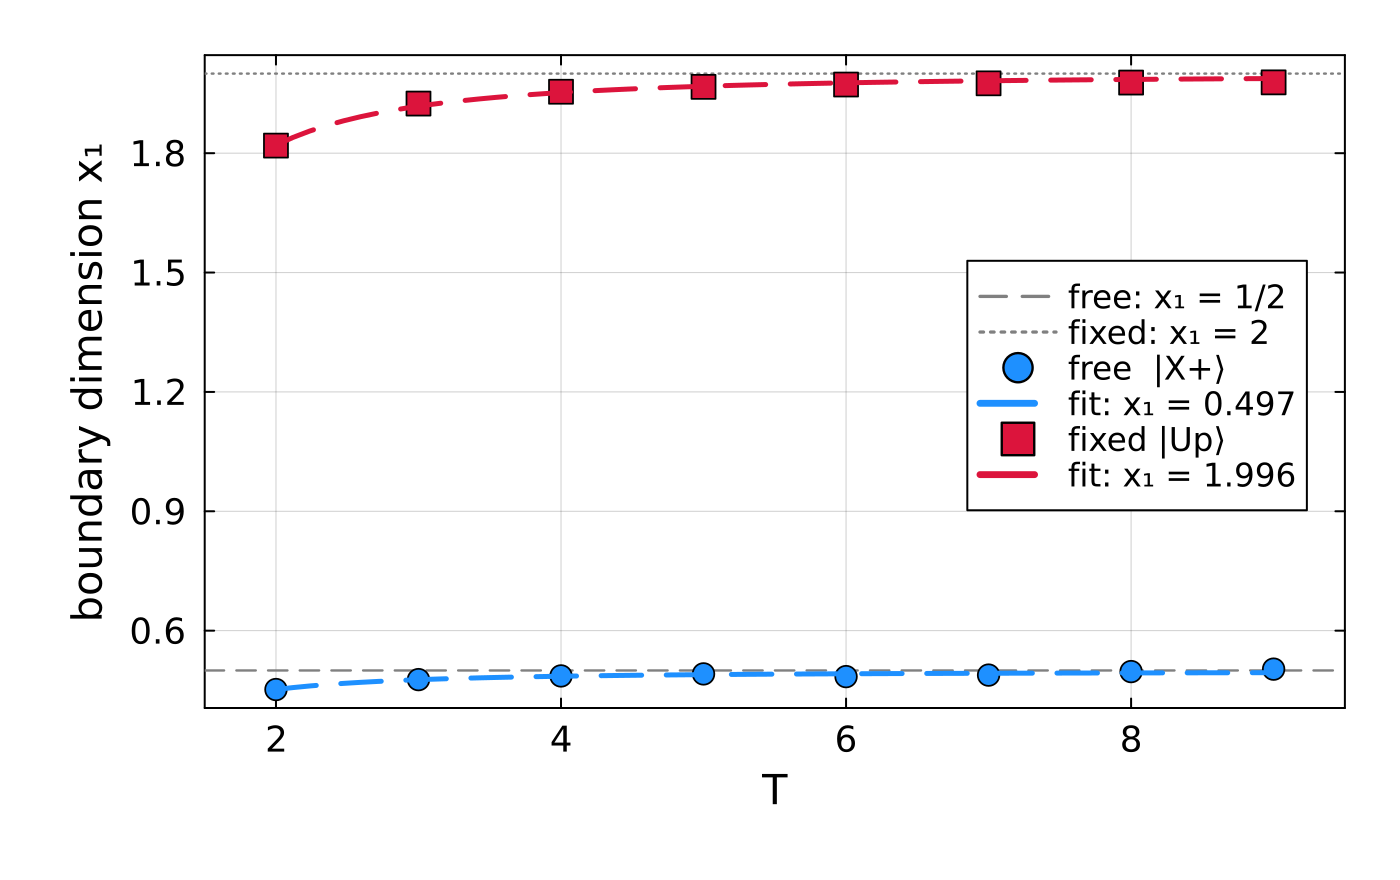

In [7]:
free_d = load_arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0")
fixed_raw = load("../results/data/nb7_alcaraz_fixedbc.jld2", "done")
fixed_d = Dict(k[2] => v for (k, v) in fixed_raw if k[1] == 0.0 && !haskey(v, :error))

x1_model(T, q) = q[1] ./ T .+ q[2] ./ T.^3

function lam1_gap(e)   # signed phase gap to the block member closest in phase to λ0
    th = e.theta; i0 = e.i0
    best = 0.0; bg = Inf
    for (i, t) in enumerate(th)
        i == i0 && continue
        g = dphw(ph(t), ph(th[i0]))
        abs(g) < bg && (bg = abs(g); best = g)
    end
    return best
end

Tlo = 2.0
Thi = min(maximum(keys(free_d)), maximum(keys(fixed_d)))

fig = plot(xlabel="T", ylabel="boundary dimension x₁", legend=:right, xlims=(Tlo - 0.5, Thi + 0.5))
hline!(fig, [0.5], color=:gray, ls=:dash, lw=1.2, label="free: x₁ = 1/2")
hline!(fig, [2.0], color=:gray, ls=:dot, lw=1.2, label="fixed: x₁ = 2")

for (name, dat, col, mk) in (("free  |X+⟩", free_d, P_COLOR[0.0], :circle),
                             ("fixed |Up⟩", fixed_d, P_COLOR[0.1], :square))
    Ts = [T for T in sort(collect(keys(dat))) if T <= Thi]
    gaps = [lam1_gap(dat[T]) for T in Ts]
    xs = [V[0.0] * T * g / pi for (T, g) in zip(Ts, gaps)]
    scatter!(fig, Ts, xs, color=col, marker=mk, ms=6, label=name)

    sel = [Tlo <= T <= Thi for T in Ts]
    fitx = curve_fit(x1_model, Ts[sel], gaps[sel], [1.0, 0.0])
    x1 = V[0.0] * fitx.param[1] / pi
    Tr = range(Tlo, Thi, length=60)
    plot!(fig, Tr, V[0.0] .* Tr .* x1_model(Tr, fitx.param) ./ pi, color=col, ls=:dash,
          label=@sprintf("fit: x₁ = %.3f", x1))
    @printf("%s  T=%g–%g  n=%d  x1=%.4f  (per-time x from %.3f to %.3f)\n",
            name, Tlo, Thi, count(sel), x1, minimum(xs), maximum(xs))
end
plot!(fig, size=(700, 440))
savefig(fig, "../results/imgs/res_x1_p0.png")
fig

The first spectral gap converted to a dimension approaches 1/2 for the free boundary and 2 for the fixed one, and the fits over the whole window give 0.49 and 1.97 against the exact values.

## The spectral route under frustration

The corrected Eq.(3) fit on the phase-tracked physical branch, per p. The measured phase advance is well under pi per rung at every coupling (0.21 radians per unit T at p=0.3), so aliasing is not what limited the coarse ladders; the rungs were lost to non-converged runs and to the old tracker's truncation, as notebook 11 established. The half-integer ladders add rungs inside the same windows. The cell also prints the B-free fit over three windows, to check whether the constant still locks onto -pi once the window is long.

p=0.5: only 2 tracked rungs, skipped

B–C degeneracy test (B free), c = 24 v |C| / π:


p=0.0  T≤ 9.0 (n= 8):  B_free=-3.142 (−π=-3.142)  C=-0.03171  ->  c=0.485


p=0.0  T≤11.0 (n=10):  B_free=-3.141 (−π=-3.142)  C=-0.03305  ->  c=0.505
p=0.0  T≤20.0 (n=19):  B_free=-3.141 (−π=-3.142)  C=-0.03237  ->  c=0.495
p=0.1  T≤ 9.0 (n= 8):  B_free=-3.144 (−π=-3.142)  C=-0.02698  ->  c=0.550
p=0.1  T≤11.0 (n=10):  B_free=-3.148 (−π=-3.142)  C=-0.01602  ->  c=0.327
p=0.1  T≤20.0 (n=10):  B_free=-3.148 (−π=-3.142)  C=-0.01602  ->  c=0.327
p=0.3  T≤ 9.0 (n=10):  B_free=-6.181 (−π=-3.142)  C=-0.01825  ->  c=0.553
p=0.3  T≤11.0 (n=10):  B_free=-6.181 (−π=-3.142)  C=-0.01825  ->  c=0.553
p=0.3  T≤20.0 (n=10):  B_free=-6.181 (−π=-3.142)  C=-0.01825  ->  c=0.553

calibrated against p=0 on a matched window:
  T<= 9.0  p=0.1:  absolute c=0.550   calibrated c=0.568
  T<= 9.0  p=0.3:  absolute c=0.553   calibrated c=0.571


  T<=11.0  p=0.1:  absolute c=0.327   calibrated c=0.324
  T<=11.0  p=0.3:  absolute c=0.553   calibrated c=0.548


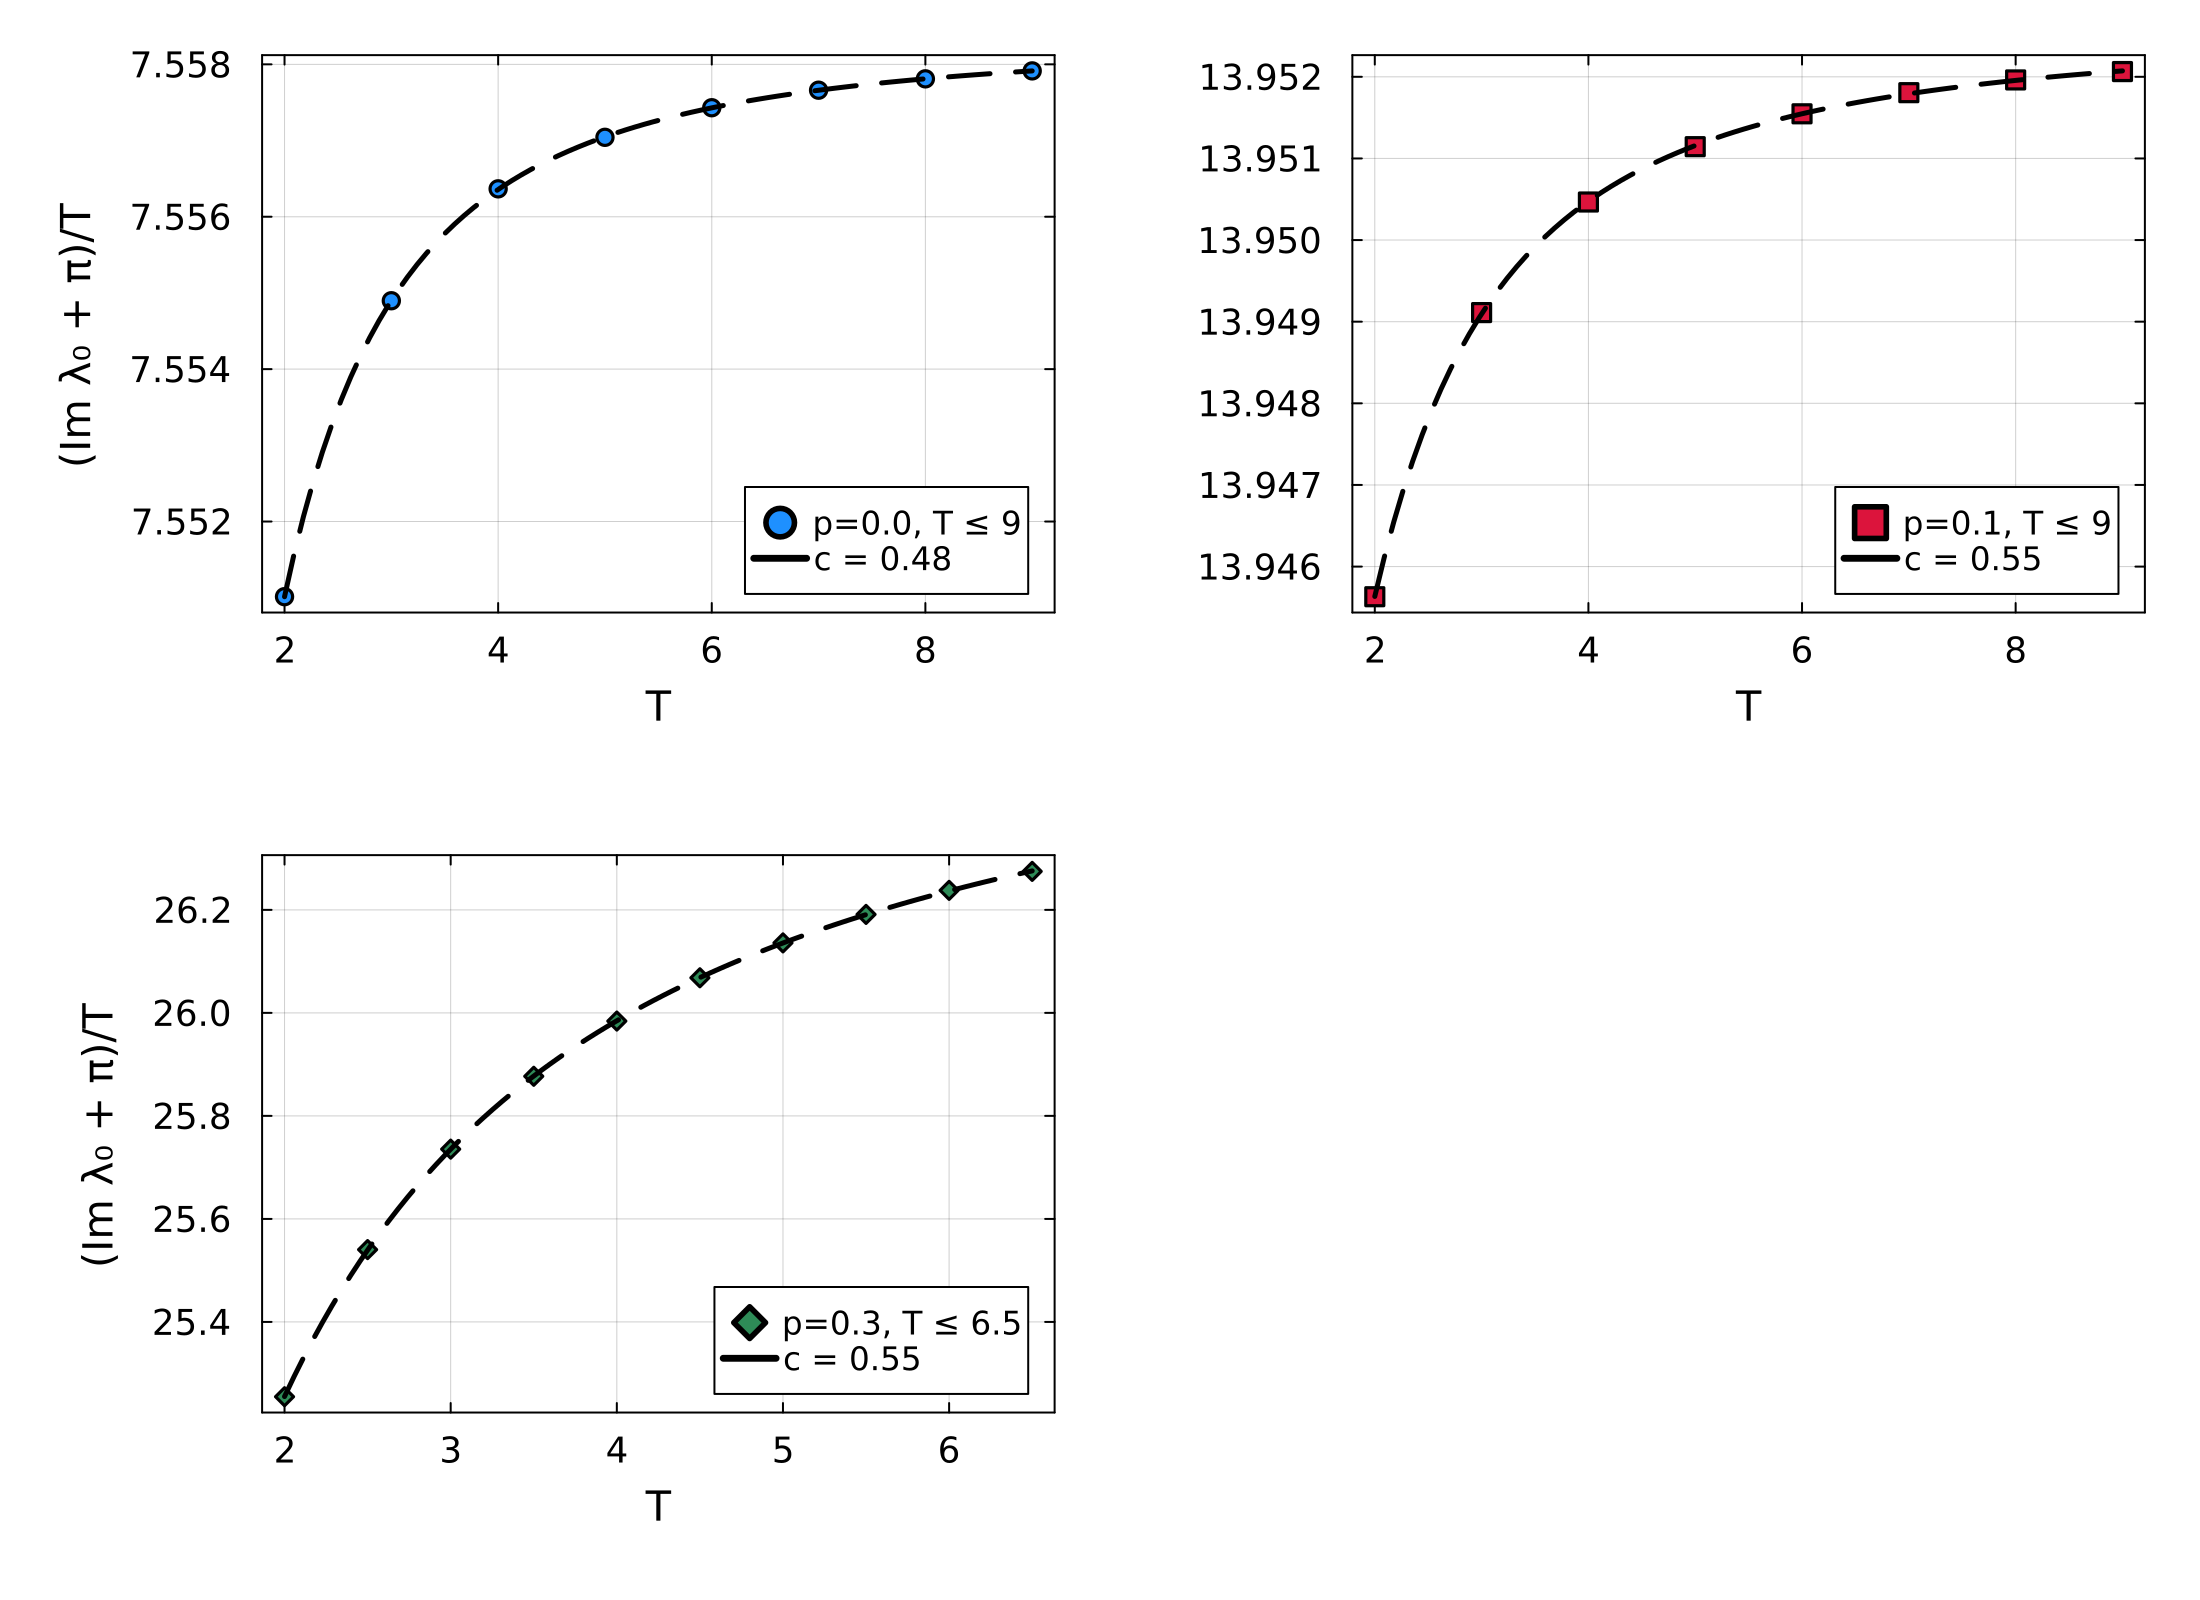

In [8]:
arms = Dict(p => load_arm("sweep_rtm_eigs_p$(p).jld2", "rtm_eigs_p$(p)") for p in (0.0, 0.1, 0.3, 0.5))

# the coarse ladder advances the phase by more than π per rung once p is large, so the branch is
# lost after a few rungs; the half-integer ladders halve the advance and the tracker holds
eig_arm = Dict(0.0 => arms[0.0], 0.1 => arms[0.1], 0.3 => fine_arm(0.3), 0.5 => fine_arm(0.5))

eq3f(T, q) = q[1] .* T .+ q[2] .+ q[3] ./ T .+ q[4] ./ T.^3   # B free
eq3p(T, q) = q[1] .* T .- pi .+ q[2] ./ T .+ q[3] ./ T.^3     # B pinned at -π

# unwrapped phase of the tracked branch, on the 2π sheet that puts the constant near -π
function tracked_phase(arm, Tmax)
    chn, Phi, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.02, okT)
    Ts = fb === nothing ? okT : okT[1:fb-1]
    phw = [Phi[T] for T in Ts]
    ff0 = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    phw = phw .- 2pi * round((ff0.param[2] + pi) / (2pi))
    keep = [i for i in eachindex(Ts) if Ts[i] <= Tmax]
    return Ts[keep], phw[keep]
end

Cs = Dict{Float64,Float64}()
panels = []
for p in (0.0, 0.1, 0.3, 0.5)
    Ts, phw = tracked_phase(eig_arm[p], 9.0)
    length(Ts) < 5 && (@printf("p=%.1f: only %d tracked rungs, skipped\n", p, length(Ts)); continue)
    fitp = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
    Cs[p] = fitp.param[3]
    pan = plot(xlabel="T", ylabel=p in (0.0, 0.3) ? "(Im λ₀ + π)/T" : "", legend=:bottomright)
    scatter!(pan, Ts, (phw .+ pi) ./ Ts, color=P_COLOR[p], marker=P_MARKER[p], ms=4.5,
             label=@sprintf("p=%.1f, T ≤ %g", p, Ts[end]))
    Tr = range(Ts[1], Ts[end], length=80)
    plot!(pan, Tr, (eq3f(Tr, fitp.param) .+ pi) ./ Tr, color=:black, ls=:dash,
          label=@sprintf("c = %.2f", 24V[p]*abs(fitp.param[3])/pi))
    push!(panels, pan)
end
fig = plot(panels..., layout=(2,2), size=(1100, 800), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_eq3_p.png")

println("\nB–C degeneracy test (B free), c = 24 v |C| / π:")
for p in (0.0, 0.1, 0.3, 0.5)
    for Tmax in (9.0, 11.0, 20.0)
        Ts, phw = tracked_phase(eig_arm[p], Tmax)
        length(Ts) < 6 && continue
        g = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0])
        @printf("p=%.1f  T≤%4.1f (n=%2d):  B_free=%+.3f (−π=%.3f)  C=%+.5f  ->  c=%.3f\n",
            p, Tmax, length(Ts), g.param[2], -pi, g.param[3], 24V[p]*abs(g.param[3])/pi)
    end
end

println("\ncalibrated against p=0 on a matched window:")
for Tmax in (9.0, 11.0)
    out = Dict{Float64,Float64}()
    for p in (0.0, 0.1, 0.3, 0.5)
        Ts, phw = tracked_phase(eig_arm[p], Tmax)
        length(Ts) < 5 && continue
        out[p] = curve_fit(eq3f, Ts, phw, [1.0, -3.0, -0.2, 0.0]).param[3]
    end
    haskey(out, 0.0) || continue
    for p in (0.1, 0.3, 0.5)
        haskey(out, p) || continue
        @printf("  T<=%4.1f  p=%.1f:  absolute c=%.3f   calibrated c=%.3f\n",
            Tmax, p, 24V[p]*abs(out[p])/pi, 0.5*abs(V[p]*out[p]/(V[0.0]*out[0.0])))
    end
end
fig

At p=0 the fit gives c = 0.48 and at p=0.1 c = 0.54 over T <= 9, the window on which B holds at -pi. One caveat from notebook 11 stands: the 0.54 comes from the unit-step ladder, whose value moves with the window, while the half-integer ladder settles at 0.42 to 0.44; the p=0 half-integer control queued on the cluster decides between them, so the p=0.1 entry is provisional.

## The displaced tower

The deep k=8 block at p=0.1 in the plane of phase gap versus relative modulus, with the two families coloured: even (identity module) near phase zero, odd (boundary fermions) entering from the pi side. One panel per available T.

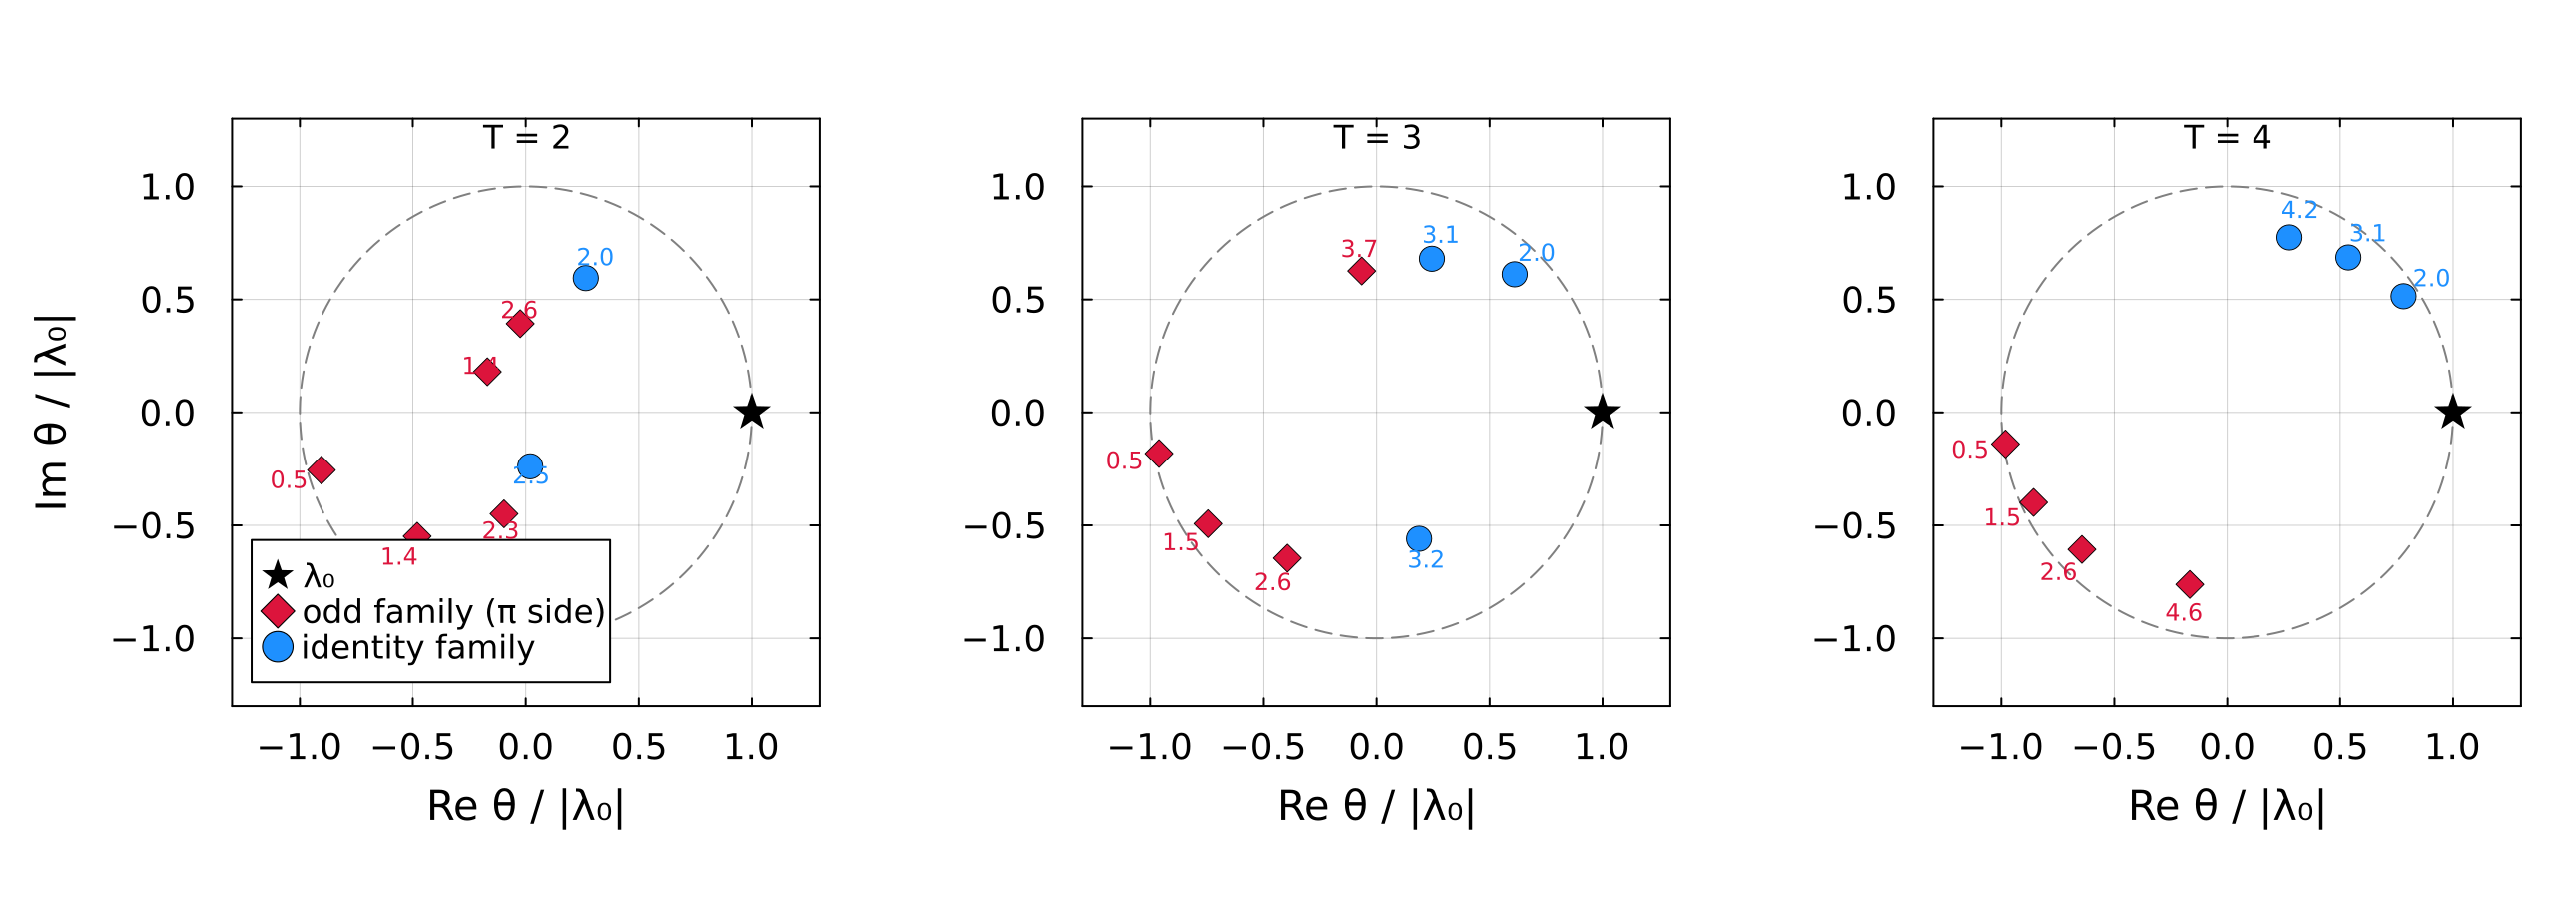

In [9]:
stress = load("../results/data/nb3_p01_stress.jld2", "done")
k8T = sort([k[2] for k in keys(stress) if k[1] == 0.1 && k[3] == 8])
v01 = V[0.1]
panels = []
for T in k8T
    e = stress[(0.1, T, 8)]
    th = collect(e.theta); i0 = argmax(abs.(th))
    lam0 = th[i0]
    pan = plot(xlabel="Re θ / |λ₀|", ylabel=(T == k8T[1] ? "Im θ / |λ₀|" : ""),
               legend=(T == k8T[1] ? :bottomleft : false), aspect_ratio=:equal,
               xlims=(-1.3, 1.3), ylims=(-1.3, 1.3))
    phis = range(0, 2pi, length=200)
    plot!(pan, cos.(phis), sin.(phis), color=:gray, ls=:dash, lw=1, label="")
    scatter!(pan, [1.0], [0.0], color=:black, marker=:star5, ms=10, label="λ₀")
    firste = true; firsto = true
    for (i, t) in enumerate(th)
        i == i0 && continue
        # divide by λ0 so the relative phase is the angle from the positive real axis
        zi = t / lam0
        g = abs(dphw(ph(t), ph(lam0)))
        even = g < pi/2
        x = even ? v01*T*g/pi : v01*T*(pi - g)/pi
        scatter!(pan, [real(zi)], [imag(zi)], color=even ? :dodgerblue : :crimson,
                 marker=even ? :circle : :diamond, ms=7, msw=0.5,
                 label=(even && firste) ? "identity family" : ((!even && firsto) ? "odd family (π side)" : ""))
        even ? (firste = false) : (firsto = false)
        annotate!(pan, 1.16*real(zi), 1.16*imag(zi), text(@sprintf("%.1f", x), 8, even ? :dodgerblue : :crimson))
    end
    annotate!(pan, 0.0, 1.22, text("T = $(Int(T))", 11))
    push!(panels, pan)
end
fig = plot(panels..., layout=(1, length(panels)), size=(430*length(panels), 460), margin=5Plots.mm, left_margin=10Plots.mm, bottom_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_tower_spectrum.png")
fig


The k=8 block splits into two groups: the identity family near the positive real axis with x = 2, 3, 4, and the displaced family near relative phase pi carrying x = 1/2, 3/2, 5/2, the odd-sector boundary operators. The lightest operator lives in the displaced group, which is why a selector reading only near lambda0 misses it.

## The tower across frustration

Boundary dimensions from the k=4 eigenvalue ladders: each captured eigenvalue is read as near-lambda0 (x = vT|dphi|/pi, even module) or pi-displaced (x = vT(pi-|dphi|)/pi, odd module). The eigenvalue-only arms extend every panel past the entropy wall.

p=0.0  lightest rung: mean x = 0.4938 over 19 points (from 0.452 to 0.506)
p=0.1  lightest rung: mean x = 0.4686 over 11 points (from 0.357 to 0.487)


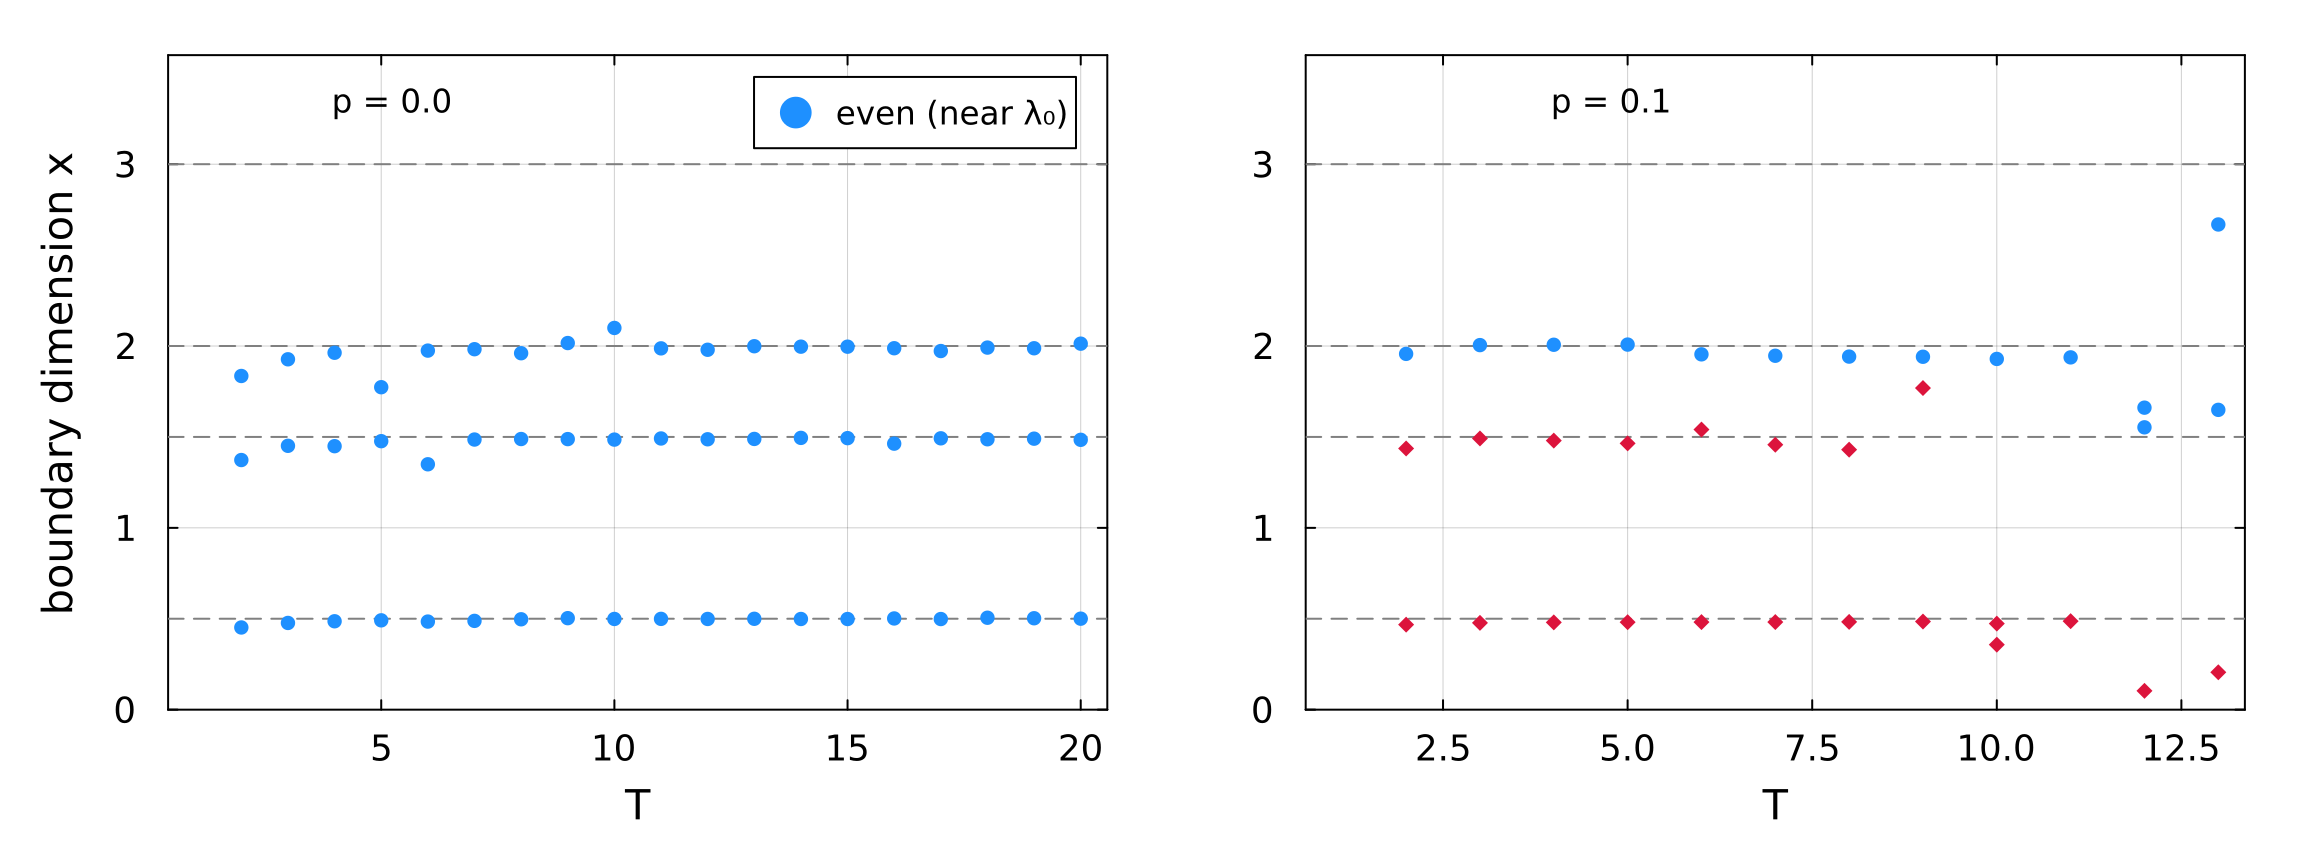

In [10]:
panels = []
dims_by_p = Dict{Float64,Vector{Float64}}()
for p in (0.0, 0.1)
    arm = arms[p]; chn, _, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.05, okT); okT = fb === nothing ? okT : okT[1:fb-1]
    pan = plot(xlabel="T", ylabel=p == 0.0 ? "boundary dimension x" : "",
               ylims=(0, 3.6), legend=(p == 0.0 ? :topright : false))
    for x in (0.5, 1.5, 2.0, 3.0); hline!(pan, [x], color=:gray, ls=:dash, lw=1.0, label=""); end
    firstev = true; firstodd = true
    dims_by_p[p] = Float64[]
    for T in okT
        e = arm[T]; th = e.theta; i0 = chn[T]
        for (i, t) in enumerate(th)
            i == i0 && continue
            g = abs(dphw(ph(t), ph(th[i0])))
            even = g < pi/2
            x = even ? V[p] * T * g / pi : V[p] * T * (pi - g) / pi
            0.05 < x < 3.6 || continue
            push!(dims_by_p[p], x)
            scatter!(pan, [T], [x], color=even ? :dodgerblue : :crimson,
                     marker=even ? :circle : :diamond, ms=4, msw=0,
                     label=(even && firstev) ? "even (near λ₀)" : ((!even && firstodd) ? "odd (π side)" : ""))
            even ? (firstev = false) : (firstodd = false)
        end
    end
    annotate!(pan, 4.0, 3.35, text("p = $(p)", 11, :left))
    push!(panels, pan)
end
# The lightest rung, quoted in the text: the states sitting near x = 1/2 across the window.
for p in (0.0, 0.1)
    lightest = [x for x in dims_by_p[p] if 0.3 < x < 0.8]
    @printf("p=%.1f  lightest rung: mean x = %.4f over %d points (from %.3f to %.3f)\n",
            p, sum(lightest)/length(lightest), length(lightest), minimum(lightest), maximum(lightest))
end

fig = plot(panels..., layout=(1,2), size=(1150, 430), margin=5Plots.mm, bottom_margin=10Plots.mm, left_margin=10Plots.mm)
savefig(fig, "../results/imgs/res_tower_across_p.png")
fig

Read per family, the same data give x1 = 0.49 at p=0 and 0.47 at p=0.1, the free-boundary Ising value at both couplings. The apparent x1 = 3/2 of a naive read was an assignment error, not physics.

## The leading spectral gap

The modulus ratio between the leading eigenvalue and the next block member, per coupling. At p=0 the companion is the first boundary rung; at p!=0 it is the pi-displaced partner, and from T~4 the two moduli agree to within two percent.

The physical branch comes from the phase tracker. Block members whose modulus exceeds it by more than 5% are unconverged outliers, so they are excluded from the choice of companion.

p=0.0  T=2–20  ratio: first=0.8898  last=0.9981  max=0.9981
p=0.1  T=2–13  ratio: first=0.9398  last=1.0201  max=1.0201


p=0.3  T=2–6  ratio: first=0.9649  last=1.0224  max=1.0224
p=0.5  T=2–3  ratio: first=0.8754  last=0.9090  max=0.9090


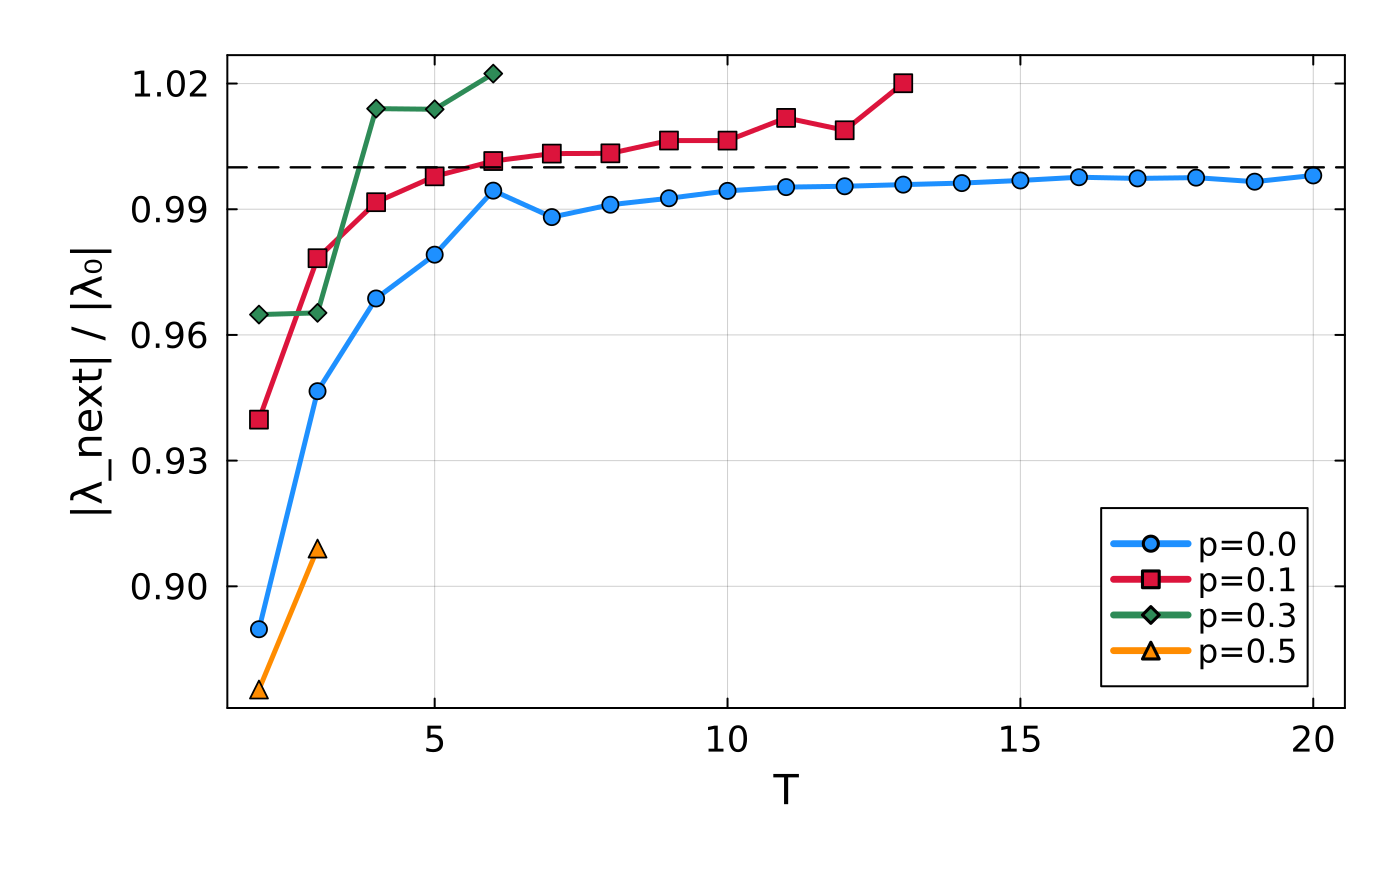

In [11]:
fig = plot(xlabel="T", ylabel="|λ_next| / |λ₀|", legend=:bottomright)
for p in (0.0, 0.1, 0.3, 0.5)
    arm = arms[p]; chn, _, okT, cst = phase_chain(arm)
    fb = findfirst(T -> cst[T] >= 0.05, okT); Ts = fb === nothing ? okT : okT[1:fb-1]
    rT = Float64[]; rv = Float64[]
    for T in Ts
        th = arm[T].theta; i0 = chn[T]
        m0 = abs(th[i0])
        cand = [abs(t) for (i, t) in enumerate(th) if i != i0 && abs(t) <= 1.05 * m0]
        isempty(cand) && continue
        push!(rT, T); push!(rv, maximum(cand) / m0)
    end
    plot!(fig, rT, rv, color=P_COLOR[p], marker=P_MARKER[p], ms=4.5, label="p=$(p)")
    @printf("p=%.1f  T=%g–%g  ratio: first=%.4f  last=%.4f  max=%.4f\n",
            p, rT[1], rT[end], rv[1], rv[end], maximum(rv))
end
hline!(fig, [1.0], color=:black, ls=:dash, lw=1.2, label="")
plot!(fig, size=(700, 440))
savefig(fig, "../results/imgs/res_partner_gap.png")
fig

The modulus ratio approaches one from below at every coupling and crosses it at T of about 6 for p=0.1 and about 4 for p=0.3. Notebook 12 settles the reading left open here: the two members are the two sectors of an exact Z2 symmetry, the crossing is symmetry-enforced, and the sector-projected ladders resolve both branches through it.